# Análisis de Ortofoto de Drone

Este notebook realiza análisis de imágenes multiespectrales capturadas por drone:
- Lee metadatos y estadísticas por banda
- Crea una composición RGB
- Calcula NDVI (Índice de Vegetación)
- Genera máscaras de vegetación
- Guarda imágenes de salida y resumen JSON

## 1. Importar librerías necesarias

In [2]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from IPython.display import Image, display

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Definir funciones auxiliares

In [20]:
def percentile_stretch(band, pmin=2, pmax=98):
    """Estira los valores de la banda usando percentiles para mejor visualización"""
    lo, hi = np.nanpercentile(band, (pmin, pmax))
    if hi <= lo:
        return np.clip(band, 0, 1)
    out = (band - lo) / (hi - lo)
    return np.clip(out, 0, 1)

def save_figure(img, path, cmap=None, title=None):
    """Guarda una imagen con matplotlib"""
    plt.figure(figsize=(10, 8))
    if cmap:
        plt.imshow(img, cmap=cmap)
        plt.colorbar(shrink=0.8)
    else:
        plt.imshow(img)
    if title:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

def compute_ndvi(red, nir):
    """Calcula el NDVI (Normalized Difference Vegetation Index)"""
    denom = (nir.astype('float32') + red.astype('float32'))
    with np.errstate(divide='ignore', invalid='ignore'):
        ndvi = (nir.astype('float32') - red.astype('float32')) / denom
    ndvi[np.isinf(ndvi)] = np.nan
    return ndvi

print(" Funciones definidas")

 Funciones definidas


## 3. Configurar archivo de entrada y directorio de salida

In [3]:
# Archivo de entrada
input_file = "Task-of-2025-10-16T171937017Z-orthophoto.tif"

# Directorio de salida
inp = Path(input_file)
outdir = inp.parent / (inp.stem + "_analysis")
outdir.mkdir(parents=True, exist_ok=True)

# Umbral NDVI para clasificar vegetación
ndvi_threshold = 0.3

print(f" Archivo de entrada: {input_file}")
print(f" Directorio de salida: {outdir}")
print(f" Umbral NDVI: {ndvi_threshold}")

 Archivo de entrada: Task-of-2025-10-16T171937017Z-orthophoto.tif
 Directorio de salida: Task-of-2025-10-16T171937017Z-orthophoto_analysis
 Umbral NDVI: 0.3


## 4. Leer metadatos y cargar bandas

In [5]:
# Inicializar resumen
summary = {
    "input": str(inp),
    "bands": None,
    "width": None,
    "height": None,
    "crs": None,
    "transform": None,
    "band_stats": {},
    "ndvi": {"computed": False},
}

# Abrir archivo TIFF
with rasterio.open(inp) as src:
    summary["bands"] = src.count
    summary["width"] = src.width
    summary["height"] = src.height
    summary["crs"] = str(src.crs) if src.crs else None
    summary["transform"] = src.transform.to_gdal() if src.transform else None
    
    print(f"\n Información de la imagen:")
    print(f"  • Bandas: {src.count}")
    print(f"  • Dimensiones: {src.width} × {src.height} píxeles")
    print(f"  • CRS: {src.crs}")
    print(f"  • Tipo de datos: {src.dtypes[0]}")
    
    # Leer todas las bandas
    bands = []
    print(f"\n Estadísticas por banda:")
    for i in range(1, src.count + 1):
        band = src.read(i).astype('float32')
        
        # Convertir valores nodata a nan
        if src.nodatavals and src.nodatavals[i-1] is not None:
            nod = src.nodatavals[i-1]
            band[band == nod] = np.nan
        
        bands.append(band)
        
        # Calcular estadísticas
        clean = band[np.isfinite(band)]
        if clean.size:
            stats = {
                "min": float(np.nanmin(band)),
                "max": float(np.nanmax(band)),
                "mean": float(np.nanmean(band)),
                "std": float(np.nanstd(band)),
            }
            summary["band_stats"][f"band_{i}"] = stats
            print(f"  Banda {i}: min={stats['min']:.1f}, max={stats['max']:.1f}, "
                  f"media={stats['mean']:.1f}, std={stats['std']:.1f}")
        else:
            summary["band_stats"][f"band_{i}"] = None
            print(f"  Banda {i}: Sin datos válidos")

print(f"\n✓ Bandas cargadas en memoria")

RasterioIOError: Task-of-2025-10-16T171937017Z-orthophoto.tif: No such file or directory

## 5. Generar composición RGB

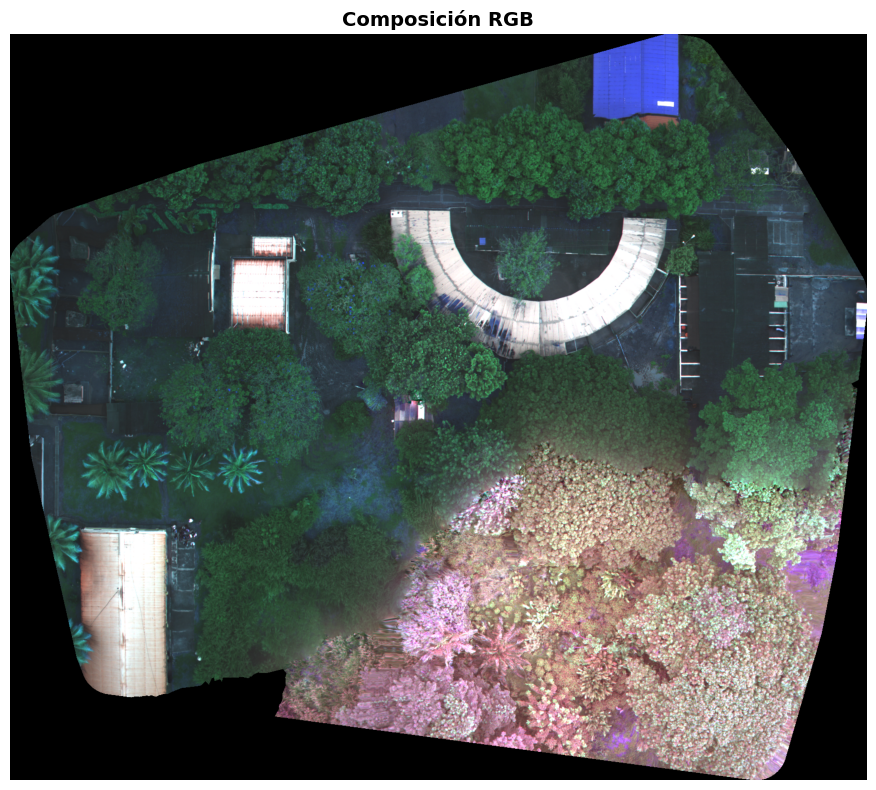

✓ Imagen RGB guardada: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_RGB.png


In [7]:
if len(bands) >= 3:
    # Asumir bandas 1=Blue, 2=Green, 3=Red
    r = bands[2]  # band 3 (Red)
    g = bands[1]  # band 2 (Green)
    b = bands[0]  # band 1 (Blue)
    
    # Normalizar por percentiles para visualización
    r_s = percentile_stretch(r)
    g_s = percentile_stretch(g)
    b_s = percentile_stretch(b)
    rgb = np.dstack([r_s, g_s, b_s])
    
    # Guardar imagen RGB
    rgb_path = outdir / f"{inp.stem}_RGB.png"
    save_figure(rgb, rgb_path, title="Composición RGB")
    summary["rgb_image"] = str(rgb_path)
    
    print(f"✓ Imagen RGB guardada: {rgb_path}")
else:
    summary["rgb_image"] = None
    print(" No hay suficientes bandas para generar composición RGB")

## 6. Calcular NDVI (Índice de Vegetación)


 Estadísticas NDVI:
  • Rango: [-1.000, 1.000]
  • Media: 0.298
  • Desviación estándar: 0.278


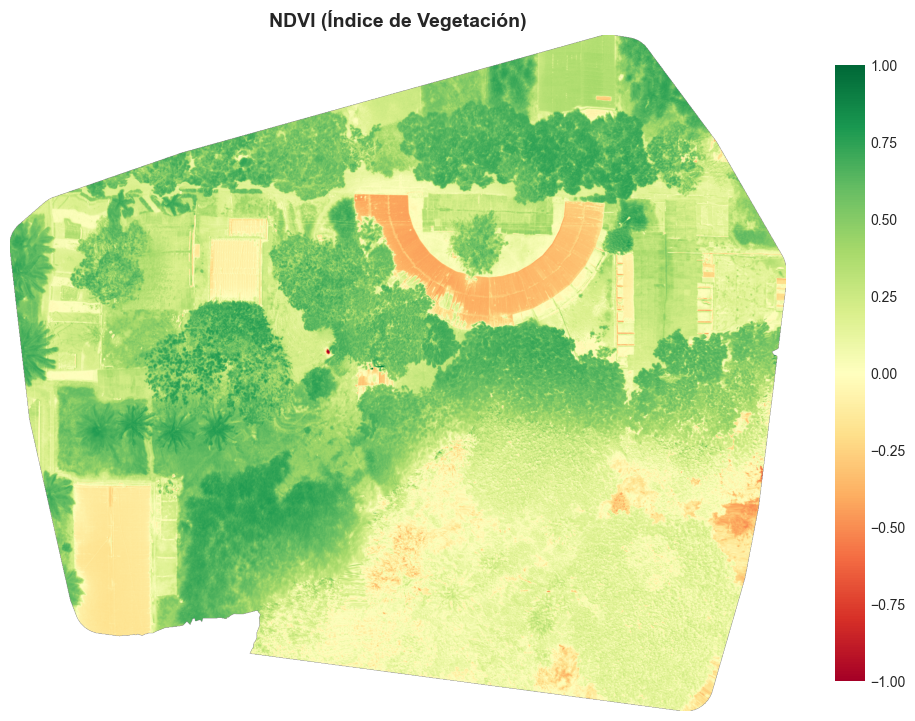

✓ Mapa NDVI guardado: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_NDVI.png


In [18]:
if len(bands) >= 4:
    # Asumir banda 3=Red, banda 4=NIR (Near Infrared)
    red = bands[2]
    nir = bands[3]
    
    # Calcular NDVI
    ndvi = compute_ndvi(red, nir)
    summary["ndvi"]["computed"] = True
    
    # Estadísticas NDVI
    ndvi_clean = ndvi[np.isfinite(ndvi)]
    if ndvi_clean.size:
        ndvi_stats = {
            "min": float(np.nanmin(ndvi)),
            "max": float(np.nanmax(ndvi)),
            "mean": float(np.nanmean(ndvi)),
            "std": float(np.nanstd(ndvi)),
        }
        summary["ndvi"].update(ndvi_stats)
        
        print(f"\n Estadísticas NDVI:")
        print(f"  • Rango: [{ndvi_stats['min']:.3f}, {ndvi_stats['max']:.3f}]")
        print(f"  • Media: {ndvi_stats['mean']:.3f}")
        print(f"  • Desviación estándar: {ndvi_stats['std']:.3f}")
    
    # Guardar mapa NDVI
    ndvi_vis = np.clip(ndvi, -1, 1)
    ndvi_path = outdir / f"{inp.stem}_NDVI.png"
    save_figure(ndvi_vis, ndvi_path, cmap='RdYlGn', title='NDVI (Índice de Vegetación)')
    summary["ndvi"]["image"] = str(ndvi_path)
    
    print(f"✓ Mapa NDVI guardado: {ndvi_path}")
else:
    summary["ndvi"]["computed"] = False
    print(" No hay suficientes bandas para calcular NDVI (se requieren al menos 4)")

## 7. Generar máscara de vegetación


🌱 Análisis de cobertura vegetal:
  • Umbral NDVI: 0.3
  • Píxeles con vegetación: 906,219
  • Cobertura vegetal: 37.18%


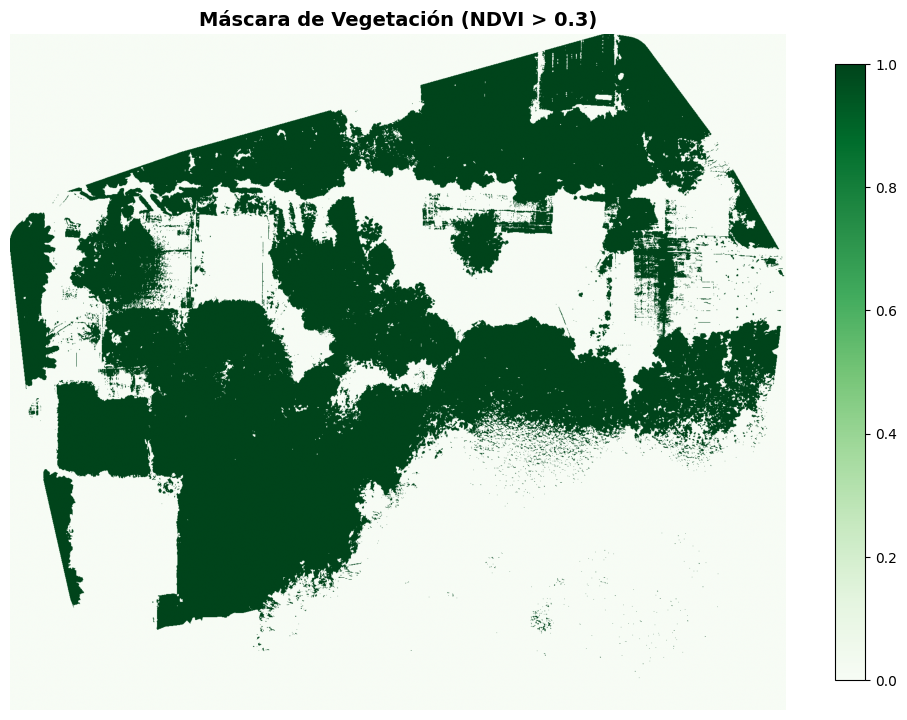

✓ Máscara de vegetación guardada: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_vegmask.png


In [ ]:
if summary["ndvi"]["computed"]:
    # Crear máscara binaria (vegetación vs no-vegetación)
    veg_mask = np.zeros(ndvi.shape, dtype=np.uint8)
    veg_mask[np.isfinite(ndvi) & (ndvi > ndvi_threshold)] = 1
    
    # Calcular porcentaje de cobertura vegetal
    veg_pct = 100.0 * (veg_mask.sum() / float(np.prod(veg_mask.shape)))
    summary["ndvi"]["veg_threshold"] = ndvi_threshold
    summary["ndvi"]["vegetation_percent"] = float(veg_pct)
    
    print(f"\n Análisis de cobertura vegetal:")
    print(f"  • Umbral NDVI: {ndvi_threshold}")
    print(f"  • Píxeles con vegetación: {veg_mask.sum():,}")
    print(f"  • Cobertura vegetal: {veg_pct:.2f}%")
    
    # Guardar máscara
    veg_path = outdir / f"{inp.stem}_vegmask.png"
    save_figure(veg_mask, veg_path, cmap='Greens', 
                title=f'Máscara de Vegetación (NDVI > {ndvi_threshold})')
    summary["ndvi"]["veg_mask"] = str(veg_path)
    
    print(f"✓ Máscara de vegetación guardada: {veg_path}")

## 8. Guardar resumen en JSON

In [ ]:
# Guardar resumen completo
summary_path = outdir / f"{inp.stem}_analysis_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"\n Análisis completado")
print(f" Resumen guardado: {summary_path}")
print(f" Todos los archivos en: {outdir}")


✅ Análisis completado
📄 Resumen guardado: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_analysis_summary.json
📁 Todos los archivos en: Task-of-2025-10-16T171937017Z-orthophoto_analysis


## 9. Visualizar resumen JSON

In [11]:
# Mostrar resumen formateado
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "input": "Task-of-2025-10-16T171937017Z-orthophoto.tif",
  "bands": 6,
  "width": 1673,
  "height": 1457,
  "crs": "EPSG:32618",
  "transform": [
    373124.94283207174,
    0.049977578475344335,
    0.0,
    487397.3793756347,
    0.0,
    -0.049993476842807485
  ],
  "band_stats": {
    "band_1": {
      "min": 0.0,
      "max": 65535.0,
      "mean": 10868.9287109375,
      "std": 9792.279296875
    },
    "band_2": {
      "min": 0.0,
      "max": 65535.0,
      "mean": 11604.1015625,
      "std": 9935.21875
    },
    "band_3": {
      "min": 0.0,
      "max": 65535.0,
      "mean": 10956.1552734375,
      "std": 11168.306640625
    },
    "band_4": {
      "min": 0.0,
      "max": 65400.0,
      "mean": 18757.048828125,
      "std": 13768.5576171875
    },
    "band_5": {
      "min": 0.0,
      "max": 63748.0,
      "mean": 17248.357421875,
      "std": 12741.8720703125
    },
    "band_6": {
      "min": 0.0,
      "max": 255.0,
      "mean": 194.9384002685547,
      "std":

## 10. Generar gráficas estadísticas

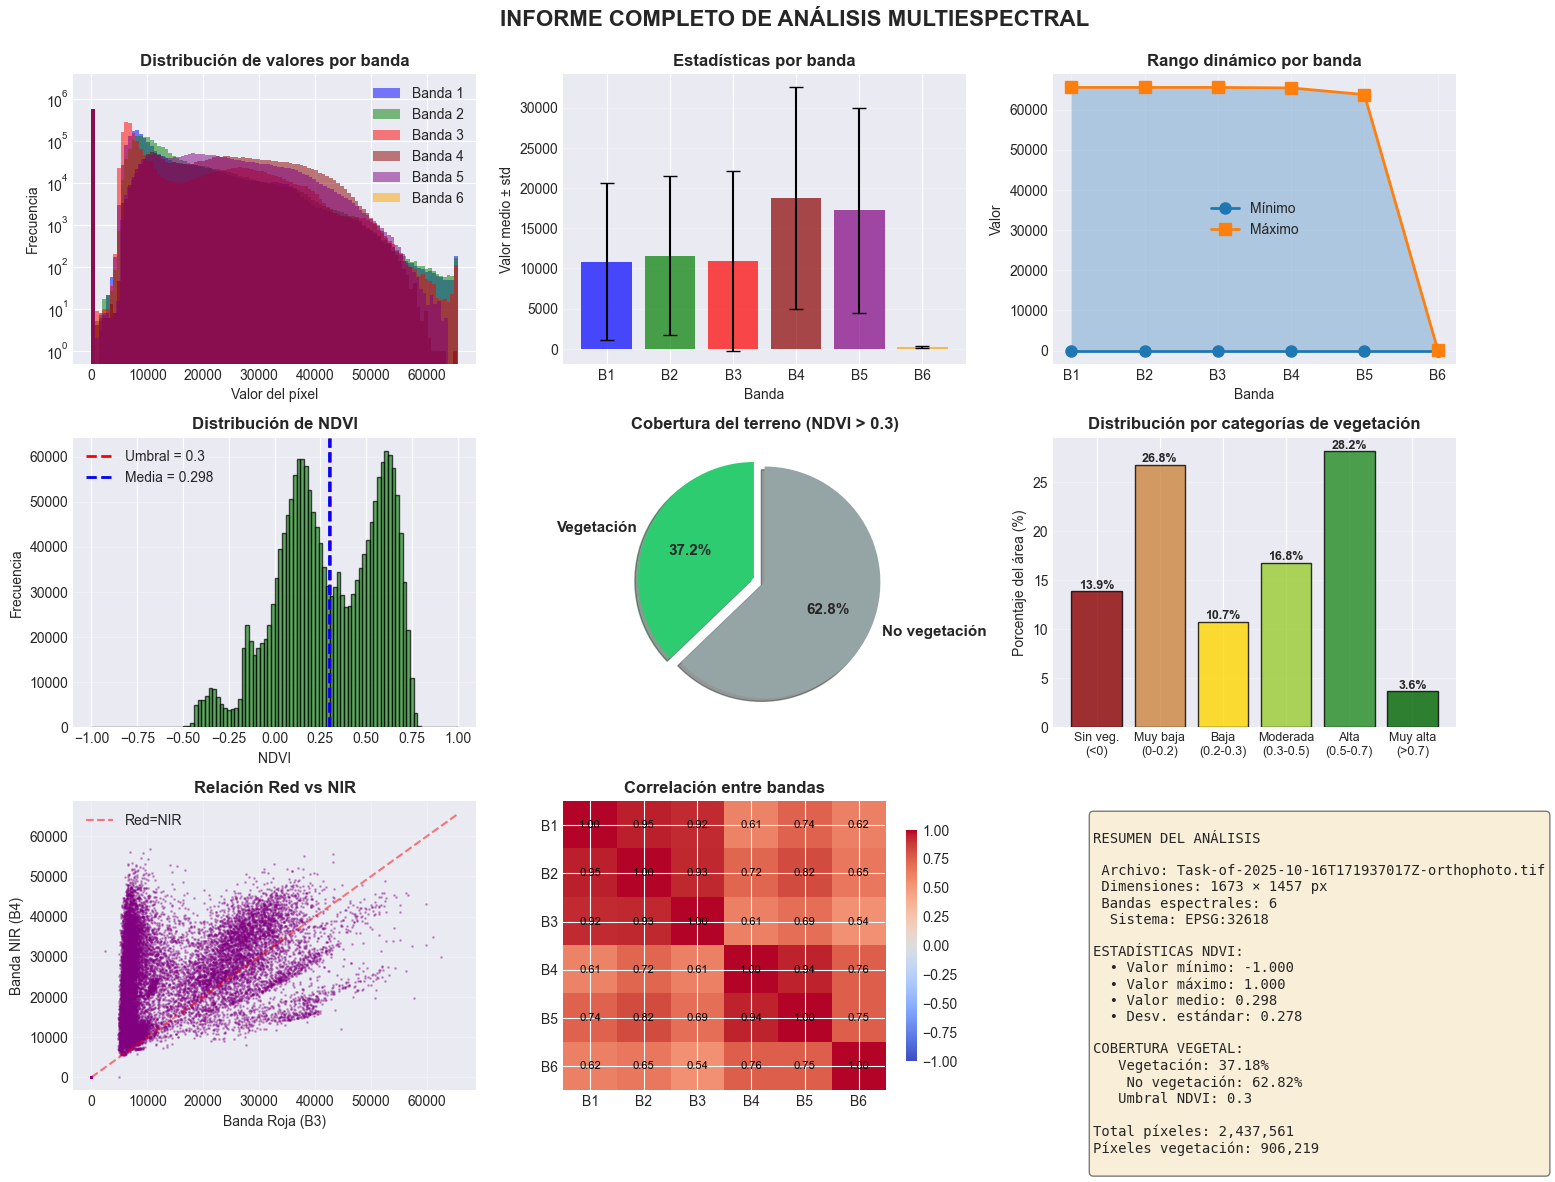


 Informe gráfico generado: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_informe_completo.png


In [17]:
# Configurar estilo de gráficas
plt.style.use('seaborn-v0_8-darkgrid')
import matplotlib.patches as mpatches

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(16, 12))

# 1. Histogramas de todas las bandas
ax1 = plt.subplot(3, 3, 1)
colors = ['blue', 'green', 'red', 'darkred', 'purple', 'orange']
for i, (band, color) in enumerate(zip(bands[:6], colors)):
    band_clean = band[np.isfinite(band)]
    ax1.hist(band_clean.flatten(), bins=100, alpha=0.5, label=f'Banda {i+1}', color=color)
ax1.set_xlabel('Valor del píxel')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de valores por banda', fontweight='bold')
ax1.legend()
ax1.set_yscale('log')

# 2. Estadísticas por banda (barras)
ax2 = plt.subplot(3, 3, 2)
band_names = [f'B{i+1}' for i in range(len(bands))]
means = [summary['band_stats'][f'band_{i+1}']['mean'] for i in range(len(bands))]
stds = [summary['band_stats'][f'band_{i+1}']['std'] for i in range(len(bands))]
x_pos = np.arange(len(band_names))
ax2.bar(x_pos, means, yerr=stds, alpha=0.7, color=colors[:len(bands)], capsize=5)
ax2.set_xlabel('Banda')
ax2.set_ylabel('Valor medio ± std')
ax2.set_title('Estadísticas por banda', fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(band_names)
ax2.grid(axis='y', alpha=0.3)

# 3. Rango de valores por banda
ax3 = plt.subplot(3, 3, 3)
mins = [summary['band_stats'][f'band_{i+1}']['min'] for i in range(len(bands))]
maxs = [summary['band_stats'][f'band_{i+1}']['max'] for i in range(len(bands))]
ax3.plot(band_names, mins, 'o-', label='Mínimo', linewidth=2, markersize=8)
ax3.plot(band_names, maxs, 's-', label='Máximo', linewidth=2, markersize=8)
ax3.fill_between(range(len(band_names)), mins, maxs, alpha=0.3)
ax3.set_xlabel('Banda')
ax3.set_ylabel('Valor')
ax3.set_title('Rango dinámico por banda', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Histograma NDVI
if summary["ndvi"]["computed"]:
    ax4 = plt.subplot(3, 3, 4)
    ndvi_clean = ndvi[np.isfinite(ndvi)]
    counts, bins, patches = ax4.hist(ndvi_clean.flatten(), bins=100, color='forestgreen', 
                                      alpha=0.7, edgecolor='black')
    ax4.axvline(ndvi_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Umbral = {ndvi_threshold}')
    ax4.axvline(summary['ndvi']['mean'], color='blue', linestyle='--', linewidth=2, 
                label=f'Media = {summary["ndvi"]["mean"]:.3f}')
    ax4.set_xlabel('NDVI')
    ax4.set_ylabel('Frecuencia')
    ax4.set_title('Distribución de NDVI', fontweight='bold')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)

    # 5. Clasificación de vegetación (gráfico de pie)
    ax5 = plt.subplot(3, 3, 5)
    veg_area = summary['ndvi']['vegetation_percent']
    non_veg_area = 100 - veg_area
    colors_pie = ['#2ecc71', '#95a5a6']
    explode = (0.1, 0)
    ax5.pie([veg_area, non_veg_area], labels=['Vegetación', 'No vegetación'],
            autopct='%1.1f%%', startangle=90, colors=colors_pie, explode=explode,
            shadow=True, textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax5.set_title(f'Cobertura del terreno (NDVI > {ndvi_threshold})', fontweight='bold')

    # 6. NDVI por categorías
    ax6 = plt.subplot(3, 3, 6)
    categories = ['Sin veg.\n(<0)', 'Muy baja\n(0-0.2)', 'Baja\n(0.2-0.3)', 
                  'Moderada\n(0.3-0.5)', 'Alta\n(0.5-0.7)', 'Muy alta\n(>0.7)']
    cat_values = [
        np.sum((ndvi_clean < 0)),
        np.sum((ndvi_clean >= 0) & (ndvi_clean < 0.2)),
        np.sum((ndvi_clean >= 0.2) & (ndvi_clean < 0.3)),
        np.sum((ndvi_clean >= 0.3) & (ndvi_clean < 0.5)),
        np.sum((ndvi_clean >= 0.5) & (ndvi_clean < 0.7)),
        np.sum((ndvi_clean >= 0.7))
    ]
    cat_percent = [v / len(ndvi_clean) * 100 for v in cat_values]
    colors_cat = ['#8B0000', '#CD853F', '#FFD700', '#9ACD32', '#228B22', '#006400']
    bars = ax6.bar(range(len(categories)), cat_percent, color=colors_cat, alpha=0.8, 
                   edgecolor='black')
    ax6.set_ylabel('Porcentaje del área (%)')
    ax6.set_title('Distribución por categorías de vegetación', fontweight='bold')
    ax6.set_xticks(range(len(categories)))
    ax6.set_xticklabels(categories, rotation=0, ha='center', fontsize=9)
    ax6.grid(axis='y', alpha=0.3)
    
    # Agregar valores en las barras
    for bar, pct in zip(bars, cat_percent):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 7. Comparación RGB vs NIR
ax7 = plt.subplot(3, 3, 7)
if len(bands) >= 4:
    # Comparar banda roja vs NIR
    red_clean = bands[2][np.isfinite(bands[2])]
    nir_clean = bands[3][np.isfinite(bands[3])]
    ax7.scatter(red_clean[::100], nir_clean[::100], alpha=0.3, s=1, c='purple')
    ax7.set_xlabel('Banda Roja (B3)')
    ax7.set_ylabel('Banda NIR (B4)')
    ax7.set_title('Relación Red vs NIR', fontweight='bold')
    ax7.grid(alpha=0.3)
    # Línea de referencia
    max_val = max(red_clean.max(), nir_clean.max())
    ax7.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Red=NIR')
    ax7.legend()

# 8. Matriz de correlación entre bandas
ax8 = plt.subplot(3, 3, 8)
correlation_matrix = np.zeros((len(bands), len(bands)))
for i in range(len(bands)):
    for j in range(len(bands)):
        b1 = bands[i][np.isfinite(bands[i])].flatten()
        b2 = bands[j][np.isfinite(bands[j])].flatten()
        correlation_matrix[i, j] = np.corrcoef(b1[::100], b2[::100])[0, 1]

im = ax8.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax8.set_xticks(range(len(bands)))
ax8.set_yticks(range(len(bands)))
ax8.set_xticklabels([f'B{i+1}' for i in range(len(bands))])
ax8.set_yticklabels([f'B{i+1}' for i in range(len(bands))])
ax8.set_title('Correlación entre bandas', fontweight='bold')
plt.colorbar(im, ax=ax8, shrink=0.8)

# Agregar valores de correlación
for i in range(len(bands)):
    for j in range(len(bands)):
        text = ax8.text(j, i, f'{correlation_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

# 9. Información general
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
info_text = f"""
RESUMEN DEL ANÁLISIS

 Archivo: {Path(input_file).name}
 Dimensiones: {summary['width']} × {summary['height']} px
 Bandas espectrales: {summary['bands']}
  Sistema: {summary['crs']}

ESTADÍSTICAS NDVI:
  • Valor mínimo: {summary['ndvi']['min']:.3f}
  • Valor máximo: {summary['ndvi']['max']:.3f}
  • Valor medio: {summary['ndvi']['mean']:.3f}
  • Desv. estándar: {summary['ndvi']['std']:.3f}

COBERTURA VEGETAL:
   Vegetación: {summary['ndvi']['vegetation_percent']:.2f}%
    No vegetación: {100 - summary['ndvi']['vegetation_percent']:.2f}%
   Umbral NDVI: {ndvi_threshold}

Total píxeles: {summary['width'] * summary['height']:,}
Píxeles vegetación: {int(summary['width'] * summary['height'] * summary['ndvi']['vegetation_percent'] / 100):,}
"""
ax9.text(0.1, 0.95, info_text, transform=ax9.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('INFORME COMPLETO DE ANÁLISIS MULTIESPECTRAL', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

# Guardar informe completo
report_path = outdir / f"{inp.stem}_informe_completo.png"
plt.savefig(report_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Informe gráfico generado: {report_path}")

## 11. Generar informe ejecutivo en PDF/HTML

In [16]:
from datetime import datetime

# Generar informe HTML
html_report = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Informe de Análisis Multiespectral - Drone</title>
    <style>
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            margin: 0;
            padding: 20px;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: #333;
        }}
        .container {{
            max-width: 1200px;
            margin: 0 auto;
            background: white;
            padding: 40px;
            border-radius: 15px;
            box-shadow: 0 10px 40px rgba(0,0,0,0.3);
        }}
        h1 {{
            color: #2c3e50;
            text-align: center;
            border-bottom: 4px solid #3498db;
            padding-bottom: 20px;
            margin-bottom: 30px;
        }}
        h2 {{
            color: #34495e;
            margin-top: 30px;
            border-left: 5px solid #3498db;
            padding-left: 15px;
        }}
        .metadata {{
            background: #ecf0f1;
            padding: 20px;
            border-radius: 10px;
            margin: 20px 0;
        }}
        .metadata-item {{
            display: flex;
            justify-content: space-between;
            padding: 10px 0;
            border-bottom: 1px solid #bdc3c7;
        }}
        .metadata-item:last-child {{
            border-bottom: none;
        }}
        .metadata-label {{
            font-weight: bold;
            color: #2c3e50;
        }}
        .metadata-value {{
            color: #7f8c8d;
        }}
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
            gap: 20px;
            margin: 20px 0;
        }}
        .stat-card {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 25px;
            border-radius: 10px;
            text-align: center;
            box-shadow: 0 4px 15px rgba(0,0,0,0.2);
            transition: transform 0.3s;
        }}
        .stat-card:hover {{
            transform: translateY(-5px);
        }}
        .stat-value {{
            font-size: 2.5em;
            font-weight: bold;
            margin: 10px 0;
        }}
        .stat-label {{
            font-size: 1em;
            opacity: 0.9;
        }}
        .band-table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        .band-table th {{
            background: #3498db;
            color: white;
            padding: 15px;
            text-align: left;
        }}
        .band-table td {{
            padding: 12px 15px;
            border-bottom: 1px solid #ecf0f1;
        }}
        .band-table tr:nth-child(even) {{
            background: #f8f9fa;
        }}
        .band-table tr:hover {{
            background: #e8f4f8;
        }}
        .image-gallery {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(350px, 1fr));
            gap: 20px;
            margin: 20px 0;
        }}
        .image-container {{
            text-align: center;
            background: #f8f9fa;
            padding: 15px;
            border-radius: 10px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        .image-container img {{
            max-width: 100%;
            border-radius: 8px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.2);
        }}
        .image-caption {{
            margin-top: 10px;
            font-weight: bold;
            color: #2c3e50;
        }}
        .alert {{
            padding: 15px;
            border-radius: 8px;
            margin: 20px 0;
        }}
        .alert-success {{
            background: #d4edda;
            border-left: 4px solid #28a745;
            color: #155724;
        }}
        .alert-info {{
            background: #d1ecf1;
            border-left: 4px solid #17a2b8;
            color: #0c5460;
        }}
        .footer {{
            text-align: center;
            margin-top: 40px;
            padding-top: 20px;
            border-top: 2px solid #ecf0f1;
            color: #7f8c8d;
        }}
        .progress-bar {{
            width: 100%;
            height: 30px;
            background: #ecf0f1;
            border-radius: 15px;
            overflow: hidden;
            margin: 10px 0;
        }}
        .progress-fill {{
            height: 100%;
            background: linear-gradient(90deg, #2ecc71 0%, #27ae60 100%);
            display: flex;
            align-items: center;
            justify-content: center;
            color: white;
            font-weight: bold;
            transition: width 1s;
        }}
    </style>
</head>
<body>
    <div class="container">
        <h1> INFORME DE ANÁLISIS MULTIESPECTRAL</h1>
        
        <div class="alert alert-info">
            <strong> Fecha del informe:</strong> {datetime.now().strftime('%d de %B de %Y, %H:%M:%S')}
        </div>
        
        <h2> Metadatos de la Imagen</h2>
        <div class="metadata">
            <div class="metadata-item">
                <span class="metadata-label">Archivo:</span>
                <span class="metadata-value">{Path(input_file).name}</span>
            </div>
            <div class="metadata-item">
                <span class="metadata-label">Dimensiones:</span>
                <span class="metadata-value">{summary['width']} × {summary['height']} píxeles</span>
            </div>
            <div class="metadata-item">
                <span class="metadata-label">Total de píxeles:</span>
                <span class="metadata-value">{summary['width'] * summary['height']:,}</span>
            </div>
            <div class="metadata-item">
                <span class="metadata-label">Bandas espectrales:</span>
                <span class="metadata-value">{summary['bands']}</span>
            </div>
            <div class="metadata-item">
                <span class="metadata-label">Sistema de coordenadas:</span>
                <span class="metadata-value">{summary['crs']}</span>
            </div>
            <div class="metadata-item">
                <span class="metadata-label">Resolución espacial:</span>
                <span class="metadata-value">~0.05 metros/píxel</span>
            </div>
        </div>
        
        <h2> Indicadores Clave</h2>
        <div class="stats-grid">
            <div class="stat-card">
                <div class="stat-label">NDVI Promedio</div>
                <div class="stat-value">{summary['ndvi']['mean']:.3f}</div>
            </div>
            <div class="stat-card">
                <div class="stat-label">Cobertura Vegetal</div>
                <div class="stat-value">{summary['ndvi']['vegetation_percent']:.1f}%</div>
            </div>
            <div class="stat-card">
                <div class="stat-label">Píxeles con Vegetación</div>
                <div class="stat-value">{int(summary['width'] * summary['height'] * summary['ndvi']['vegetation_percent'] / 100):,}</div>
            </div>
            <div class="stat-card">
                <div class="stat-label">Desviación NDVI</div>
                <div class="stat-value">{summary['ndvi']['std']:.3f}</div>
            </div>
        </div>
        
        <h2> Análisis de Cobertura Vegetal</h2>
        <div class="alert alert-success">
            <strong>Resultado:</strong> El área analizada presenta una cobertura vegetal del 
            <strong>{summary['ndvi']['vegetation_percent']:.2f}%</strong> considerando un umbral NDVI de {ndvi_threshold}.
        </div>
        
        <div class="progress-bar">
            <div class="progress-fill" style="width: {summary['ndvi']['vegetation_percent']:.1f}%">
                {summary['ndvi']['vegetation_percent']:.1f}% Vegetación
            </div>
        </div>
        
        <h2> Estadísticas por Banda Espectral</h2>
        <table class="band-table">
            <thead>
                <tr>
                    <th>Banda</th>
                    <th>Mínimo</th>
                    <th>Máximo</th>
                    <th>Media</th>
                    <th>Desv. Estándar</th>
                </tr>
            </thead>
            <tbody>
"""

# Agregar estadísticas de cada banda
for i in range(summary['bands']):
    band_key = f'band_{i+1}'
    if summary['band_stats'][band_key]:
        stats = summary['band_stats'][band_key]
        html_report += f"""
                <tr>
                    <td><strong>Banda {i+1}</strong></td>
                    <td>{stats['min']:.2f}</td>
                    <td>{stats['max']:.2f}</td>
                    <td>{stats['mean']:.2f}</td>
                    <td>{stats['std']:.2f}</td>
                </tr>
"""

html_report += f"""
            </tbody>
        </table>
        
        <h2> Galería de Resultados</h2>
        <div class="image-gallery">
            <div class="image-container">
                <img src="{Path(summary['rgb_image']).name}" alt="Composición RGB">
                <div class="image-caption">Composición RGB en Color Verdadero</div>
            </div>
            <div class="image-container">
                <img src="{Path(summary['ndvi']['image']).name}" alt="Mapa NDVI">
                <div class="image-caption">Mapa de Índice de Vegetación (NDVI)</div>
            </div>
            <div class="image-container">
                <img src="{Path(summary['ndvi']['veg_mask']).name}" alt="Máscara de Vegetación">
                <div class="image-caption">Máscara de Cobertura Vegetal</div>
            </div>
            <div class="image-container">
                <img src="{inp.stem}_informe_completo.png" alt="Informe Completo">
                <div class="image-caption">Análisis Estadístico Completo</div>
            </div>
        </div>
        
        <h2> Interpretación de Resultados</h2>
        <div class="metadata">
            <p><strong>NDVI (Normalized Difference Vegetation Index):</strong></p>
            <ul>
                <li>Valores entre <strong>-1 y 0</strong>: Agua, nubes, nieve</li>
                <li>Valores entre <strong>0 y 0.2</strong>: Suelo desnudo, rocas</li>
                <li>Valores entre <strong>0.2 y 0.3</strong>: Vegetación dispersa o enferma</li>
                <li>Valores entre <strong>0.3 y 0.5</strong>: Vegetación moderada</li>
                <li>Valores entre <strong>0.5 y 0.7</strong>: Vegetación densa</li>
                <li>Valores <strong>mayores a 0.7</strong>: Vegetación muy densa y saludable</li>
            </ul>
            
            <p><strong>Resultados de este análisis:</strong></p>
            <ul>
                <li>NDVI promedio de <strong>{summary['ndvi']['mean']:.3f}</strong> indica vegetación {'moderada' if 0.3 <= summary['ndvi']['mean'] < 0.5 else 'densa' if summary['ndvi']['mean'] >= 0.5 else 'dispersa'}</li>
                <li>Cobertura vegetal del <strong>{summary['ndvi']['vegetation_percent']:.2f}%</strong> del área total</li>
                <li>Desviación estándar de <strong>{summary['ndvi']['std']:.3f}</strong> indica {'alta variabilidad' if summary['ndvi']['std'] > 0.3 else 'moderada variabilidad' if summary['ndvi']['std'] > 0.15 else 'baja variabilidad'} en la cobertura</li>
            </ul>
        </div>
        
        <div class="footer">
            <p> Informe generado automáticamente mediante análisis multiespectral</p>
            <p> Directorio de resultados: {outdir}</p>
            <p> Archivo JSON: {inp.stem}_analysis_summary.json</p>
        </div>
    </div>
</body>
</html>
"""

# Guardar informe HTML
html_path = outdir / f"{inp.stem}_informe.html"
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_report)

print(f" Informe HTML generado: {html_path}")
print(f" Abre el archivo en tu navegador para ver el informe completo")

 Informe HTML generado: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_informe.html
 Abre el archivo en tu navegador para ver el informe completo


## 12. Generar comparativas avanzadas

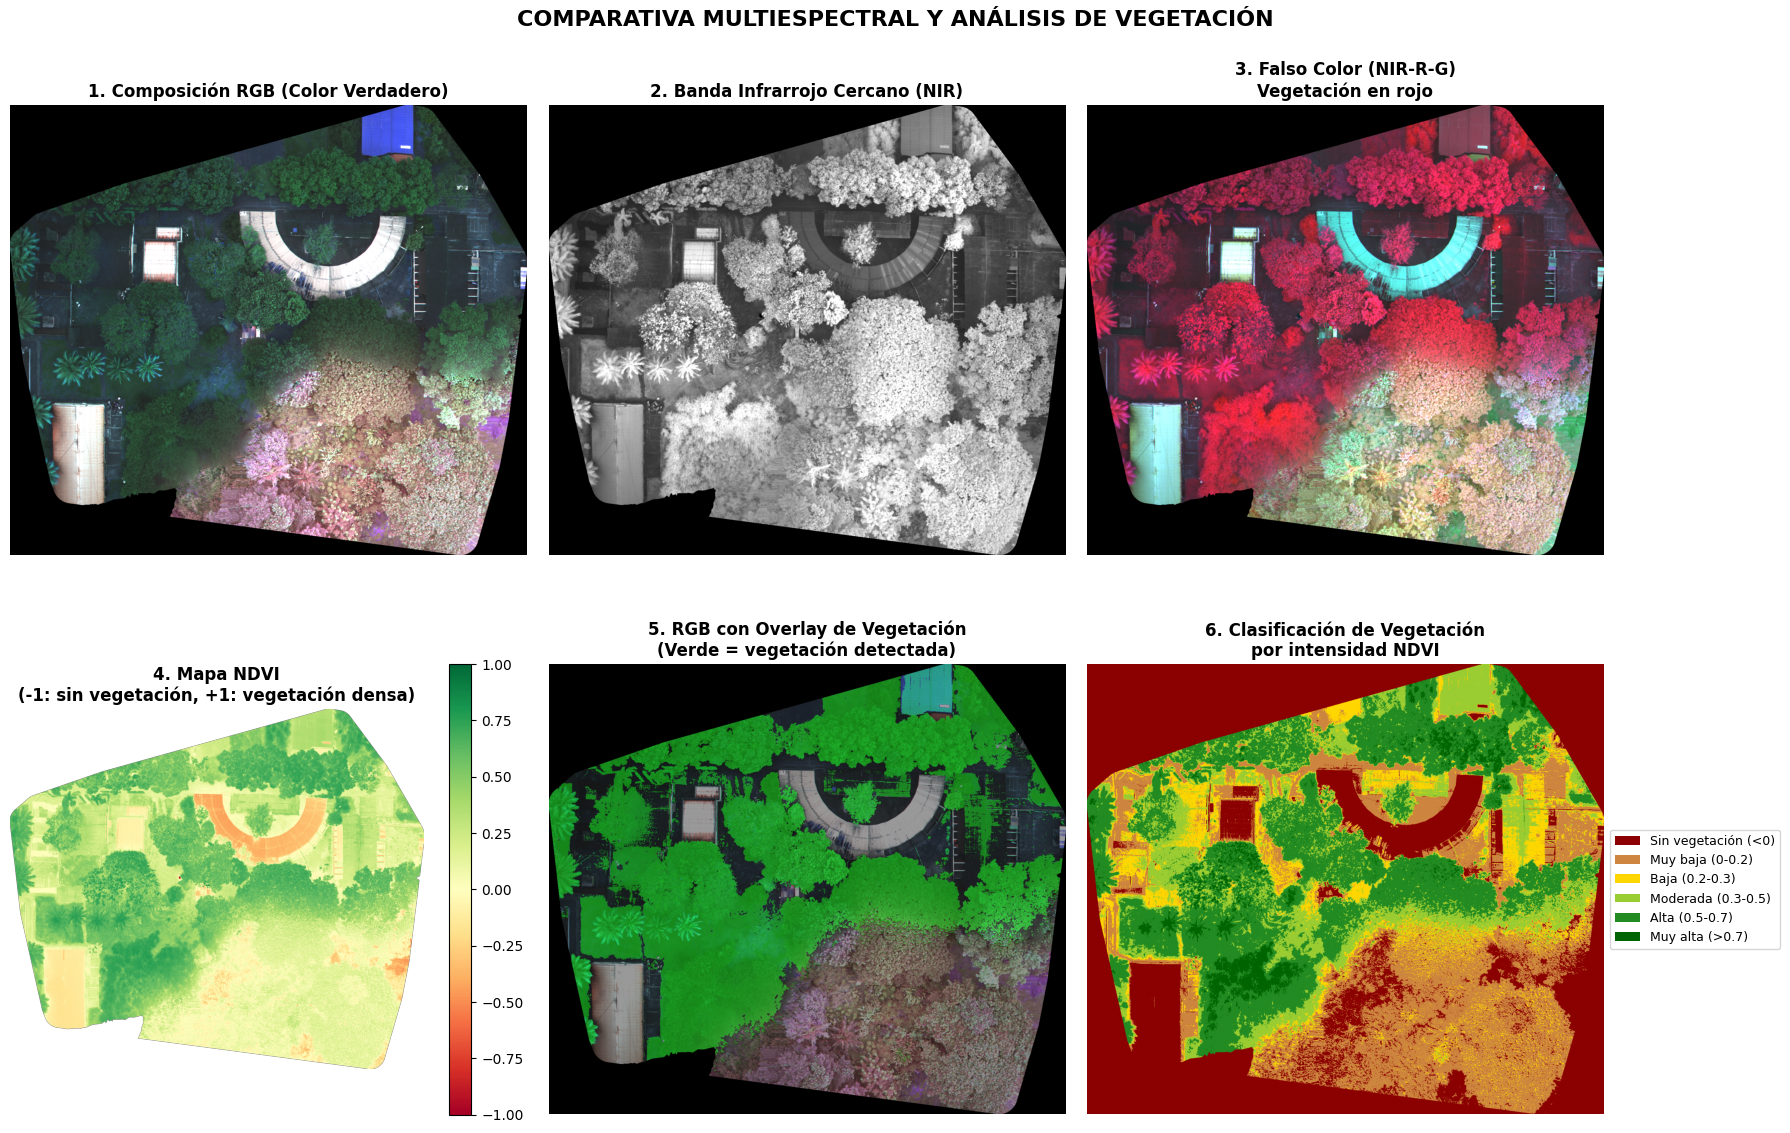

✅ Comparativa generada: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_comparativa.png


In [13]:
# Crear visualización comparativa lado a lado
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. RGB Original
axes[0, 0].imshow(rgb)
axes[0, 0].set_title('1. Composición RGB (Color Verdadero)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# 2. Banda NIR en escala de grises
if len(bands) >= 4:
    nir_normalized = percentile_stretch(bands[3])
    axes[0, 1].imshow(nir_normalized, cmap='gray')
    axes[0, 1].set_title('2. Banda Infrarrojo Cercano (NIR)', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

# 3. Composición falso color (NIR-R-G)
if len(bands) >= 4:
    nir_s = percentile_stretch(bands[3])
    r_s = percentile_stretch(bands[2])
    g_s = percentile_stretch(bands[1])
    false_color = np.dstack([nir_s, r_s, g_s])
    axes[0, 2].imshow(false_color)
    axes[0, 2].set_title('3. Falso Color (NIR-R-G)\nVegetación en rojo', fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')

# 4. Mapa NDVI con colormap
if summary["ndvi"]["computed"]:
    ndvi_display = np.clip(ndvi, -1, 1)
    im1 = axes[1, 0].imshow(ndvi_display, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1, 0].set_title('4. Mapa NDVI\n(-1: sin vegetación, +1: vegetación densa)', 
                         fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    plt.colorbar(im1, ax=axes[1, 0], shrink=0.8)

# 5. Máscara de vegetación sobre RGB
if summary["ndvi"]["computed"]:
    rgb_with_mask = rgb.copy()
    # Crear overlay verde semi-transparente donde hay vegetación
    green_overlay = np.zeros_like(rgb)
    green_overlay[:, :, 1] = veg_mask  # Canal verde
    # Mezclar
    rgb_masked = rgb * 0.6 + green_overlay * 0.4
    axes[1, 1].imshow(rgb_masked)
    axes[1, 1].set_title('5. RGB con Overlay de Vegetación\n(Verde = vegetación detectada)', 
                         fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')

# 6. Clasificación por niveles de NDVI
if summary["ndvi"]["computed"]:
    # Crear imagen clasificada
    ndvi_classified = np.zeros_like(ndvi)
    ndvi_classified[ndvi < 0] = 0          # Sin vegetación
    ndvi_classified[(ndvi >= 0) & (ndvi < 0.2)] = 1   # Muy baja
    ndvi_classified[(ndvi >= 0.2) & (ndvi < 0.3)] = 2 # Baja
    ndvi_classified[(ndvi >= 0.3) & (ndvi < 0.5)] = 3 # Moderada
    ndvi_classified[(ndvi >= 0.5) & (ndvi < 0.7)] = 4 # Alta
    ndvi_classified[ndvi >= 0.7] = 5                   # Muy alta
    
    from matplotlib.colors import ListedColormap
    colors_class = ['#8B0000', '#CD853F', '#FFD700', '#9ACD32', '#228B22', '#006400']
    cmap_class = ListedColormap(colors_class)
    
    im2 = axes[1, 2].imshow(ndvi_classified, cmap=cmap_class, vmin=0, vmax=5)
    axes[1, 2].set_title('6. Clasificación de Vegetación\npor intensidad NDVI', 
                         fontsize=12, fontweight='bold')
    axes[1, 2].axis('off')
    
    # Crear leyenda personalizada
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#8B0000', label='Sin vegetación (<0)'),
        Patch(facecolor='#CD853F', label='Muy baja (0-0.2)'),
        Patch(facecolor='#FFD700', label='Baja (0.2-0.3)'),
        Patch(facecolor='#9ACD32', label='Moderada (0.3-0.5)'),
        Patch(facecolor='#228B22', label='Alta (0.5-0.7)'),
        Patch(facecolor='#006400', label='Muy alta (>0.7)')
    ]
    axes[1, 2].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), 
                      fontsize=9)

plt.suptitle('COMPARATIVA MULTIESPECTRAL Y ANÁLISIS DE VEGETACIÓN', 
             fontsize=16, fontweight='bold')
plt.tight_layout()

# Guardar comparativa
comparative_path = outdir / f"{inp.stem}_comparativa.png"
plt.savefig(comparative_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" Comparativa generada: {comparative_path}")

## 13. Resumen de archivos generados

In [15]:
# Listar todos los archivos generados
import os

print("=" * 80)
print(" ARCHIVOS GENERADOS EN EL ANÁLISIS")
print("=" * 80)

output_files = []
for file in outdir.iterdir():
    if file.is_file():
        size = file.stat().st_size
        size_mb = size / (1024 * 1024)
        output_files.append({
            'nombre': file.name,
            'ruta': str(file),
            'tamaño': f"{size_mb:.2f} MB" if size_mb >= 1 else f"{size / 1024:.2f} KB",
            'extension': file.suffix
        })

# Organizar por tipo
imagenes = [f for f in output_files if f['extension'] in ['.png', '.jpg', '.jpeg']]
datos = [f for f in output_files if f['extension'] in ['.json', '.csv', '.txt']]
otros = [f for f in output_files if f not in imagenes and f not in datos]

if imagenes:
    print("\n  IMÁGENES GENERADAS:")
    for i, img in enumerate(imagenes, 1):
        print(f"   {i}. {img['nombre']}")
        print(f"       Tamaño: {img['tamaño']}")
        print(f"       Ruta: {img['ruta']}")
        print()

if datos:
    print(" ARCHIVOS DE DATOS:")
    for i, data in enumerate(datos, 1):
        print(f"   {i}. {data['nombre']}")
        print(f"       Tamaño: {data['tamaño']}")
        print(f"       Ruta: {data['ruta']}")
        print()

print("=" * 80)
print(f" TOTAL DE ARCHIVOS: {len(output_files)}")
print(f" Directorio: {outdir}")
print("=" * 80)

# Crear un índice en texto
index_path = outdir / "INDICE_ARCHIVOS.txt"
with open(index_path, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("ÍNDICE DE ARCHIVOS GENERADOS - ANÁLISIS MULTIESPECTRAL\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Fecha: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}\n")
    f.write(f"Archivo analizado: {input_file}\n")
    f.write(f"Directorio de salida: {outdir}\n\n")
    
    f.write("IMÁGENES:\n")
    for img in imagenes:
        f.write(f"  - {img['nombre']} ({img['tamaño']})\n")
    
    f.write("\nDATOS:\n")
    for data in datos:
        f.write(f"  - {data['nombre']} ({data['tamaño']})\n")
    
    f.write(f"\nTotal de archivos: {len(output_files)}\n")

print(f"\n Índice guardado: {index_path}")

 ARCHIVOS GENERADOS EN EL ANÁLISIS

  IMÁGENES GENERADAS:
   1. Task-of-2025-10-16T171937017Z-orthophoto_comparativa.png
       Tamaño: 15.71 MB
       Ruta: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_comparativa.png

   2. Task-of-2025-10-16T171937017Z-orthophoto_NDVI.png
       Tamaño: 1.55 MB
       Ruta: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_NDVI.png

   3. Task-of-2025-10-16T171937017Z-orthophoto_RGB.png
       Tamaño: 2.22 MB
       Ruta: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_RGB.png

   4. Task-of-2025-10-16T171937017Z-orthophoto_vegmask.png
       Tamaño: 848.03 KB
       Ruta: Task-of-2025-10-16T171937017Z-orthophoto_analysis/Task-of-2025-10-16T171937017Z-orthophoto_vegmask.png

 ARCHIVOS DE DATOS:
   1. Task-of-2025-10-16T171937017Z-orthophoto_analysis_summary.json
       Tamaño: 1.55 KB
       Ruta: Task-of-2025-10-16T17193